# Question: 
### How does the admission rates of the Colorado School of Mines and MIT compare to other post-secondary education institutes?

## Study:
### This is a census study because it is looking at all post-secondary institutions in the United States.

In [2]:
import pandas
import seaborn as sb
import matplotlib as mb
import numpy as np

In [3]:
college = pandas.read_csv("cleaned_college.csv")

In [ ]:
rate = college["admission_rate"]
admission_rate_percent = []

for i in rate:
    admission_rate_percent.append((i * 100))

# college2 = college.assign(admission_rate_percentage=admission_rate_percent)
college.insert(loc=27, column="admission_rate_percent", value=admission_rate_percent)

mines = college[college["school_name"] == "Colorado School of Mines"]["admission_rate"].values[0]
mit = college[college["school_name"] == "Massachusetts Institute of Technology"]["admission_rate"].values[0]
mean = rate.mean()
std = rate.std()
zmines = (mines - mean) / std
zmit = (mit - mean) / std
print(mines)
print(mit)
print(zmines)
print(zmit)

0.6069
0.0455
-0.5217992060910758
-2.94908506675131


C:\Users\dgarrett2\AppData\Local\Temp\ipykernel_9356\3970613787.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  college2 = college.assign(admission_rate_percentage=admission_rate_percent)


In [5]:
print(len(rate.value_counts(dropna=True)))
print(college[college["school_name"] == "Amridge University"]["admission_rate"].values[0])

1520
nan


not including all 4363 open admission colleges


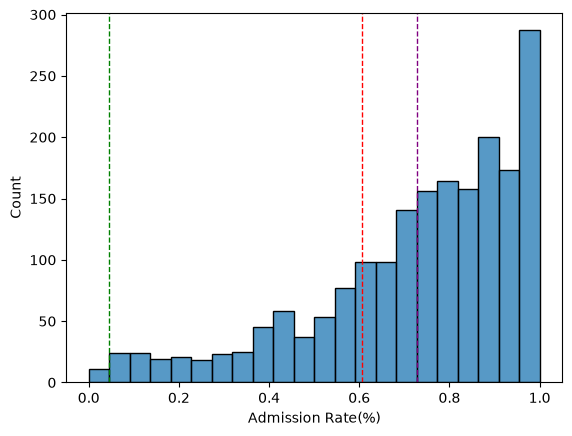

In [8]:
n = 0
for i in admission_rate_percent:
    if(np.isnan(i) == True):
        n+=1

print(f"not including all {n} open admission colleges")
plot = sb.histplot(
    x=rate,
)
mb.pyplot.xlabel("Admission Rate(%)")
plot.axvline(mean, color="purple", linestyle="--", linewidth=1, label=f"mean: {mean:.2f}")
plot.axvline(mines, color="red", linestyle="--", linewidth=1, label=f"mines: {mines:.2f}")
plot.axvline(mit, color="green", linestyle="--", linewidth=1, label=f"mit: {mit:.2f}")

# Conclusion:
### The Colorado School of Mines has a z-score of about -0.5, and MIT has a z-score of about -3.0, so MIT is an outlier and mines is not an outlier.